In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
insights = pd.read_csv('/kaggle/input/summer-products-and-sales-in-ecommerce-wish/computed_insight_success_of_active_sellers.csv')
products = pd.read_csv('/kaggle/input/summer-products-and-sales-in-ecommerce-wish/summer-products-with-rating-and-performance_2020-08.csv')

### Lets see our DATA

In [ ]:
insights.head(5)

In [ ]:
products.head(2)

In [ ]:
insights.info()

In [ ]:
products.info()

# Cleaning

## Insights Data Cleaning

#### Its clear That the column names have to be changed so i will do

In [ ]:
insights.columns = ['merchant_id', 'listed_products', 'total_units_sold',
       'mean_units_sold_per_product', 'rating', 'merchant_ratings_count',
       'mean_product_prices', 'mean_retail_prices', 'average_discount',
       'mean_discount', 'mean_product_ratings_count', 'total_urgency_count',
       'urgency_text_rate']

In [ ]:
insights['total_urgency_count'].value_counts()

#####**I guess in total_urgency_count, urgency_text_rate columns the missing values is ment to be 0 ---> 0 mean there is no urgency so i will fill the nulls with 0**

In [ ]:
insights[['total_urgency_count', 'urgency_text_rate']] = insights[['total_urgency_count', 'urgency_text_rate']].fillna(value=0)

In [ ]:
insights.duplicated().sum()

**Well there is no duplicated rows**

In [ ]:
insights[insights['average_discount'] ==	insights['mean_discount']]['merchant_id'].count()

**we found 834 of the data have average_discount equal to mean_discount which is strange i thought they are the same**

**Lets figure it out**

In [ ]:
insights[insights['average_discount'] !=	insights['mean_discount']][['average_discount','mean_discount']].head(5)

Okey they are the same i guess it was bad storage or scraping so i will delet mean_discount

In [1]:
insights.drop('mean_discount', axis=1, inplace=True)

NameError: name 'insights' is not defined

## products Data cleaning

First we can see from data info the countrating_count is begger than the ratengs columns which is strange what value can user rate is its not from 1 to 5 !!! lets see that  


In [ ]:
products[products['rating_five_count'].isna()].head(2)

**oh its clear now its non becouse the product have no rateing yet xDDD**

Lets make them zeros

In [ ]:
products[['rating_five_count','rating_four_count',
          'rating_three_count',	'rating_two_count',
          'rating_one_count']] = products[['rating_five_count','rating_four_count',
                                           'rating_three_count',	'rating_two_count',
                                           'rating_one_count']].fillna(value=0)

lets see why there is missing in product_color column

In [ ]:
products['product_color'].value_counts()

Okey they are alot and bad stored so for now i will make the nulls undefind

In [ ]:
products['product_color'].fillna(value='undefind', inplace=True)

Lets see product_variation_size_id

In [ ]:
products['product_variation_size_id'].value_counts()

Wow so many sizes too

In [ ]:
products['product_variation_size_id'].fillna(value='undefind', inplace=True)

Now lets see has_urgency_banner which have so much missing

In [ ]:
products['has_urgency_banner'].value_counts()

**Okey so Logic that when there is no banner the value will be 0, becouse there is only 1 value ( 1 )**

In [ ]:
products['has_urgency_banner'].fillna(value=0, inplace=True)
products['urgency_text'].fillna(value='No Banner', inplace=True)


I found there is missing value in origin_country, thats sad actully i dont need to reamove so i wll make it Undifind for now

In [ ]:
products['origin_country'].fillna(value='Undifind', inplace=True)

why there is merchant_name nulls !! lets see

In [ ]:
products[products['merchant_name'].isna()].head()

**I thibk it was bad storage he and the name is the title actully so i will copy the title to name, There is only one merchant ( DERNMUUR ) have this problem**

In [ ]:
# Replace values in 'merchant_name' where 'merchant_title' is 'DERNMUUR'
products.loc[products['merchant_title'] == 'DERNMUUR', 'merchant_name'] = products['merchant_title']


There is only 1 missin in merchant_info_subtitle

In [ ]:
products['merchant_info_subtitle'].fillna(value='Undifind', inplace=True)


**We have so much missing in merchant_profile_picture column its sure that it's not requerd to register in the website i will send this data to the web or someing that use the image i should replace it with placehoder but for ML or analysis i dont even need this coulmn**

So i will Delet the merchant_profile_picture

In [ ]:
products.drop(['merchant_profile_picture'], axis=1, inplace=True)

Lets check for duplicated and delet them if exists

In [ ]:
products.duplicated().sum()

In [ ]:
products.drop_duplicates(inplace=True)
print(products.duplicated().sum())

**while EDA i found crawl_month have only one monther xDD so i will drop this column its unsful**

In [ ]:
products['crawl_month'].value_counts()

In [ ]:
products.drop(['crawl_month'], axis=1, inplace=True)

#### **ITs perfect for now we will back for cleaning again if we need to after EDA to train the Outliers or if someing appers to US**

In [ ]:
products.info()

In [ ]:
insights.info()

# Power Bi DashBoard

You can find the link of the Dashboard to be intractive in : https://github.com/YahiaOmar/Data-analysis-with-Power-BI/tree/main/Wish%20E-commerce

## 1- Overview


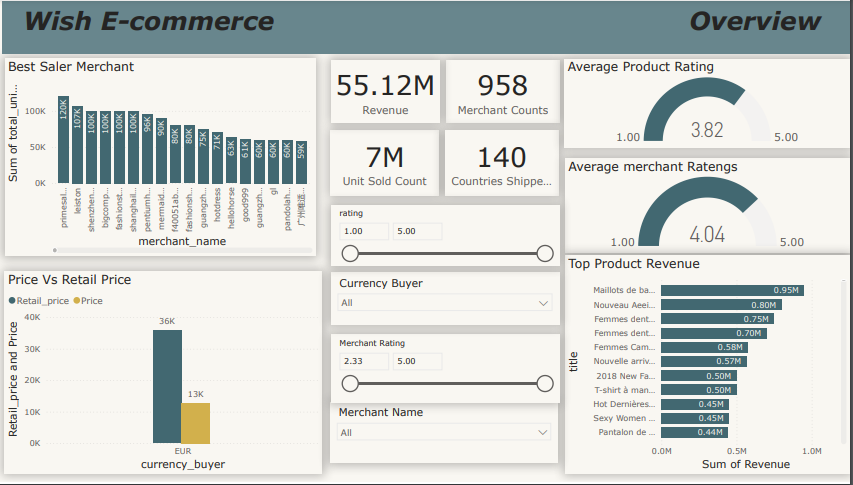

## 2- Sales Performance Analysis

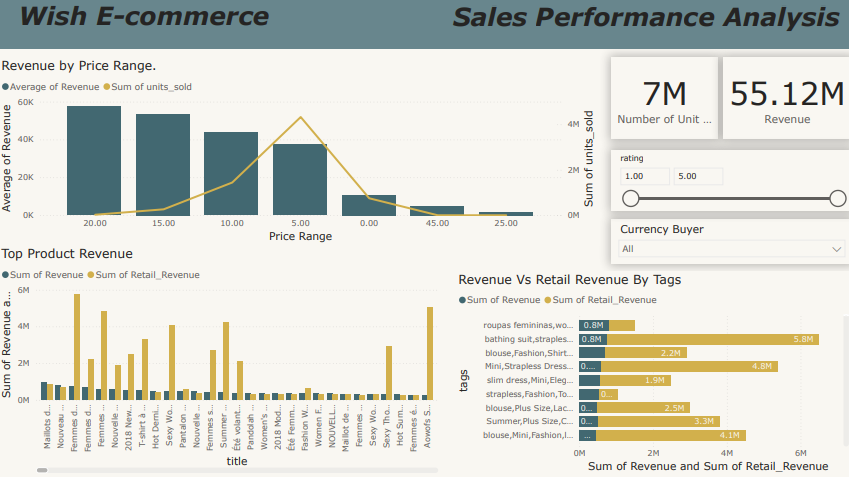

## 3- Product Variants & Attributes

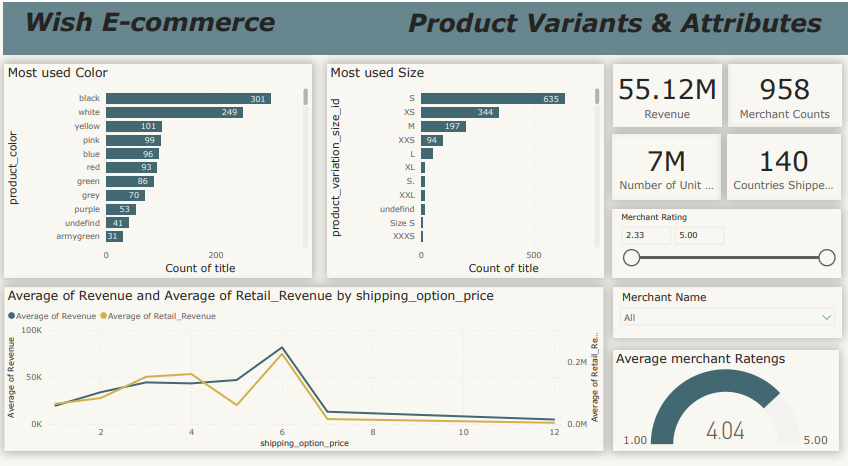

## 4- Customer Satisfaction

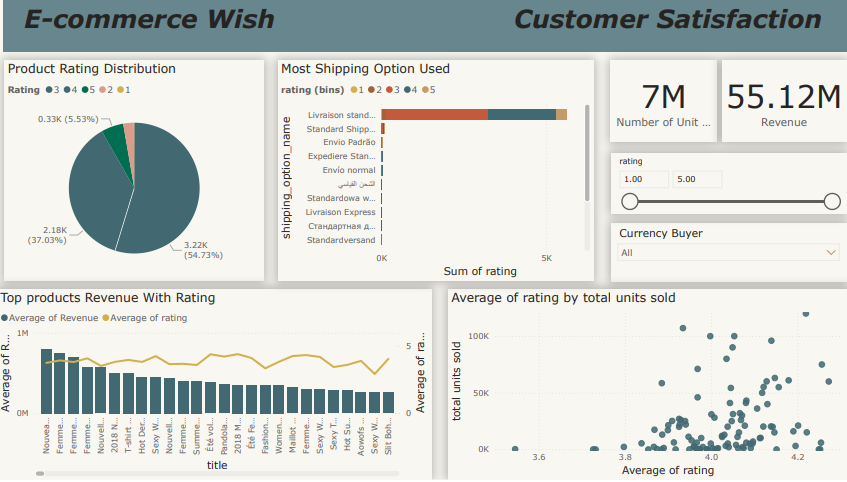

## 5- Merchant Performance

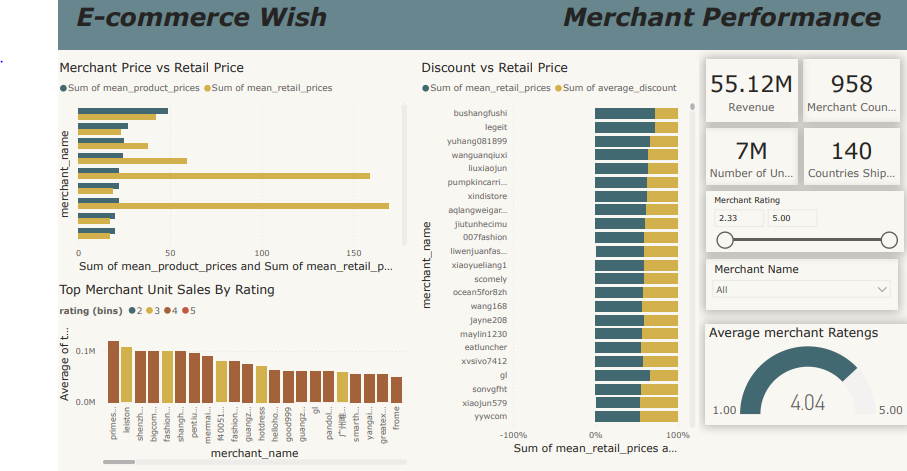